In [10]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Path to your shuffled file
zip_path = '/content/drive/MyDrive/CBS_Data/final_processed_shuffled.7z'
extract_path = '/content/CBS_Data'

os.makedirs(extract_path, exist_ok=True)

print("Extracting shuffled data...")

!apt-get install -y p7zip-full > /dev/null
!7z x "{zip_path}" -o"{extract_path}" -y

print("Extraction completed!")
print("Files available:", os.listdir(extract_path))
print("Inside shuffled folder:", os.listdir(os.path.join(extract_path, 'final_processed_shuffled')))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting shuffled data...

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/CBS_Data/                                          1 file, 102194505 bytes (98 MiB)

Extracting archive: /content/drive/MyDrive/CBS_Data/final_processed_shuffled.7z
--
Path = /content/drive/MyDrive/CBS_Data/final_processed_shuffled.7z
Type = 7z
Physical Size = 102194505
Headers Size = 260
Method = LZMA2:25
Solid = +
Blocks = 1

  0%      1% 1 - final_processed_shuffled/X_packet.npy                                              

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight   # ← Correct import

# Load the data
data_path = '/content/CBS_Data/final_processed_shuffled'

X_packet = np.load(os.path.join(data_path, 'X_packet.npy'))
X_stats = np.load(os.path.join(data_path, 'X_stats.npy'))
y = np.load(os.path.join(data_path, 'y_labels.npy'))

print(f"Loaded shapes: X_packet={X_packet.shape}, X_stats={X_stats.shape}, y={y.shape}")

# Remap labels to 0-based
unique_labels = np.unique(y)
label_map = {old: new for new, old in enumerate(unique_labels)}
y_mapped = np.array([label_map[label] for label in y])

print(f"Mapped to {len(unique_labels)} classes: {np.unique(y_mapped)}")

# Global shuffle
print("Performing global shuffle...")
X_packet, X_stats, y_mapped = shuffle(X_packet, X_stats, y_mapped, random_state=42)

# Compute class weights correctly
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_mapped),
    y=y_mapped
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

# To categorical
num_classes = len(unique_labels)
y_cat = to_categorical(y_mapped, num_classes=num_classes)

# Train-test split
X_p_train, X_p_test, X_s_train, X_s_test, y_train, y_test = train_test_split(
    X_packet, X_stats, y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y_mapped
)

print(f"Training samples: {len(X_p_train)} | Test samples: {len(X_p_test)}")

# ====================== IMPROVED CBS MODEL ======================

input_packet = layers.Input(shape=(1500, 1))

# Spatial CNN
x = layers.Conv1D(64, 5, activation='relu', padding='same')(input_packet)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)
x = layers.GlobalAveragePooling1D()(x)
cnn_out = layers.Dense(128, activation='relu')(x)

# Temporal Bi-LSTM
lstm_input = layers.Reshape((1500, 1))(input_packet)
lstm = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2))(lstm_input)
lstm = layers.Bidirectional(layers.LSTM(32, dropout=0.2))(lstm)
lstm_out = layers.Dense(128, activation='relu')(lstm)

# Statistical Branch
stats_input = layers.Input(shape=(6,))
s = layers.Dense(64, activation='relu')(stats_input)
s = layers.BatchNormalization()(s)
s = layers.Dense(128, activation='relu')(s)
sae_out = layers.Dense(64, activation='relu')(s)

# Fusion
merged = layers.Concatenate()([cnn_out, lstm_out, sae_out])
merged = layers.Dense(256, activation='relu')(merged)
merged = layers.BatchNormalization()(merged)
merged = layers.Dropout(0.4)(merged)
output = layers.Dense(num_classes, activation='softmax')(merged)

model = models.Model(inputs=[input_packet, stats_input], outputs=output)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# Training
history = model.fit(
    [X_p_train, X_s_train], y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# Evaluation
test_loss, test_acc = model.evaluate([X_p_test, X_s_test], y_test)
print(f"\nFinal Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

y_pred = model.predict([X_p_test, X_s_test])
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_test_classes, y_pred_classes, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_classes, y_pred_classes))

Loaded shapes: X_packet=(247754, 1500), X_stats=(247754, 6), y=(247754,)
Mapped to 4 classes: [0 1 2 3]
Performing global shuffle...
Class weights: {0: np.float64(23.03402751952399), 1: np.float64(97.3875786163522), 2: np.float64(4.992624536514589), 3: np.float64(0.2669498282497856)}
Training samples: 198203 | Test samples: 49551


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 1500, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1500, 64)  │        384 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1500, 64)  │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 750, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 750, 128)  │     41,088 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 750, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1500, 1)   │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 64)        │        448 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 375, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 1500, 128) │     33,792 │ reshape_2[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_16[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling1d_5[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 64)        │     41,216 │ bidirectional_4[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 128)       │      8,320 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 128)       │      8,320 │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 64)        │      8,256 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 320)       │          0 │ dense_14[0][0],   │
│ (Concatenate)       │                   │            │ dense_15[0][0],   │
│                     │                   │            │ dense_18[0][0]  

 Total params: 243,588 (951.52 KB)

 Trainable params: 242,564 (947.52 KB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 256s 401ms/step - accuracy: 0.5554 - loss: 1.2517 - val_accuracy: 0.4383 - val_loss: 1.1972 - learning_rate: 0.0010
Epoch 2/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 247s 399ms/step - accuracy: 0.7251 - loss: 0.7762 - val_accuracy: 0.7601 - val_loss: 0.6142 - learning_rate: 0.0010
Epoch 3/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 247s 399ms/step - accuracy: 0.7976 - loss: 0.5447 - val_accuracy: 0.5108 - val_loss: 1.1330 - learning_rate: 0.0010
Epoch 4/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 247s 399ms/step - accuracy: 0.8304 - loss: 0.4611 - val_accuracy: 0.8369 - val_loss: 0.4405 - learning_rate: 0.0010
Epoch 5/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 247s 399ms/step - accuracy: 0.8538 - loss: 0.4061 - val_accuracy: 0.2283 - val_loss: 2.9610 - learning_rate: 0.0010
Epoch 6/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 247s 398ms/step - accuracy: 0.8681 - loss: 0.3867 - val_accuracy: 0.8258 - val_loss: 0.5172 - learning_rate: 0.0010
Epoch 7/20
620/620 ━━━━━━━━━━━━━━━━━━━━ 247s 398ms/step - accura

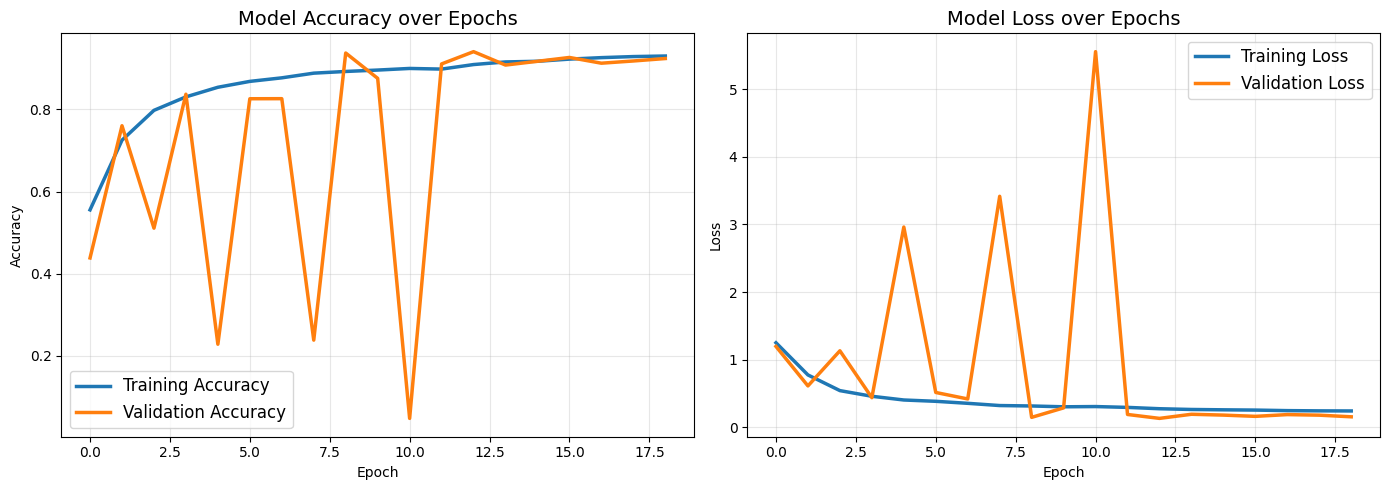

Training curves saved as 'training_curves.png'


In [11]:
# Training and Validation Curves
# Common imports for all visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from itertools import cycle
from google.colab import files
# Training and Validation Curves
plt.figure(figsize=(14, 5))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2.5)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5)
plt.title('Model Accuracy over Epochs', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2.5)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2.5)
plt.title('Model Loss over Epochs', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training curves saved as 'training_curves.png'")

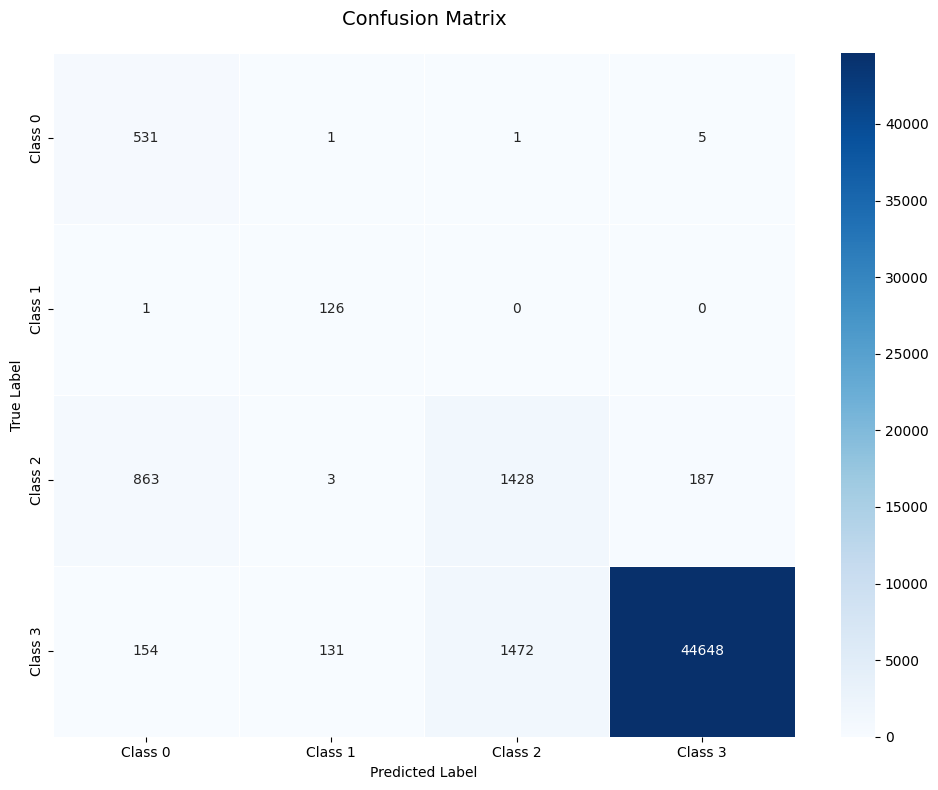

Confusion Matrix saved as 'confusion_matrix.png'


In [12]:
# Enhanced Confusion Matrix with percentages
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Plot with both counts and percentages
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            xticklabels=[f"Class {i}" for i in range(num_classes)],
            yticklabels=[f"Class {i}" for i in range(num_classes)])

plt.title('Confusion Matrix', fontsize=14, pad=20)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion Matrix saved as 'confusion_matrix.png'")

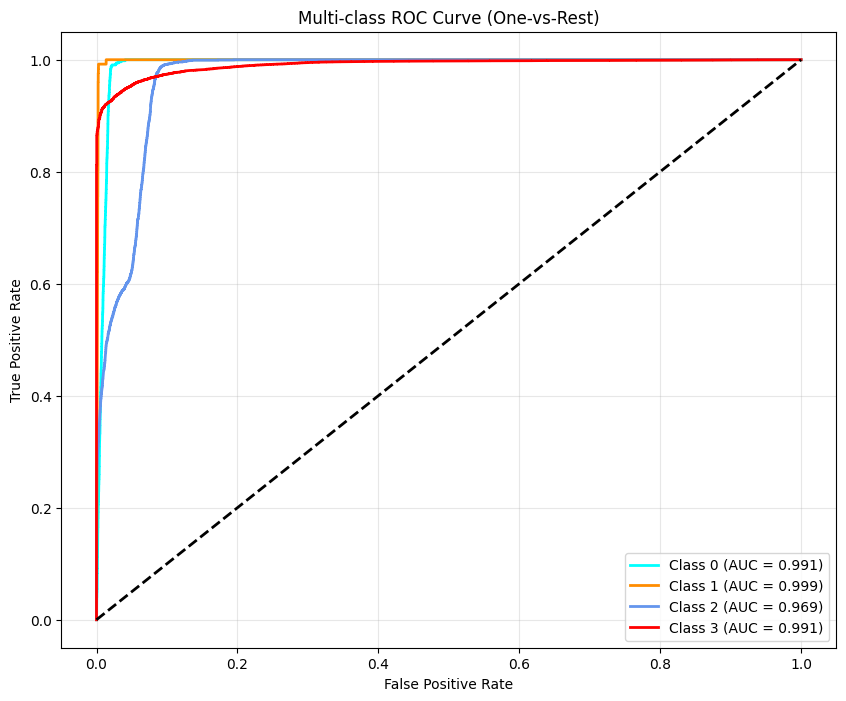

ROC Curve saved as 'roc_curve.png'


In [13]:
# ROC Curve for multi-class
from itertools import cycle
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green'])
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:0.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("ROC Curve saved as 'roc_curve.png'")

In [14]:
from google.colab import files

files.download('training_curves.png')
files.download('confusion_matrix.png')
files.download('roc_curve.png')

print("All plots downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All plots downloaded!
